In [2]:
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('CUDA devices:', torch.cuda.device_count())

Torch: 2.9.0+cu126
CUDA available: True
CUDA devices: 2


## Configuration

In [3]:
DATA_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
SAVE_DIR = '/kaggle/working/mae_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_SIZE = 224
PATCH_SIZE = 16
MASK_RATIO = 0.75
BATCH_SIZE = 32
EPOCHS = 50
LR = 1.5e-4
WEIGHT_DECAY = 0.05
NUM_WORKERS = 4
GRAD_CLIP = 1.0
SEED = 42
AMP = True

## Utilities and Dataset

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class TinyImageNetSelfSupervised(Dataset):
    def __init__(self, root: str, split: str = 'train', image_size: int = 224):
        self.root = Path(root)
        self.split = split
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

        if split == 'train':
            self.image_paths = sorted((self.root / 'train').glob('*/images/*.JPEG'))
        elif split == 'val':
            self.image_paths = sorted((self.root / 'val' / 'images').glob('*.JPEG'))
        else:
            raise ValueError('split must be train or val')

        if len(self.image_paths) == 0:
            raise FileNotFoundError(f'No images found under {self.root} for split={split}')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)

## MAE Model (Base PyTorch Layers)

In [5]:
class MLP(nn.Module):
    def __init__(self, dim: int, mlp_ratio: float = 4.0, drop: float = 0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.fc2(x))
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MAEViT(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        enc_dim=768,
        enc_depth=12,
        enc_heads=12,
        dec_dim=384,
        dec_depth=12,
        dec_heads=6,
        mask_ratio=0.75,
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, enc_dim)
        self.num_patches = self.patch_embed.num_patches
        self.patch_dim = patch_size * patch_size * in_chans

        self.enc_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, enc_dim))
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(enc_dim, enc_heads) for _ in range(enc_depth)
        ])
        self.enc_norm = nn.LayerNorm(enc_dim)

        self.enc_to_dec = nn.Linear(enc_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.dec_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, dec_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(dec_dim, dec_heads) for _ in range(dec_depth)
        ])
        self.dec_norm = nn.LayerNorm(dec_dim)
        self.dec_pred = nn.Linear(dec_dim, self.patch_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.enc_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.dec_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def patchify(self, imgs):
        p = self.patch_size
        b, c, h, w = imgs.shape
        x = imgs.reshape(b, c, h // p, p, w // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).contiguous()
        x = x.reshape(b, (h // p) * (w // p), p * p * c)
        return x

    def unpatchify(self, patches):
        p = self.patch_size
        b, n, _ = patches.shape
        h = w = int(math.sqrt(n))
        x = patches.reshape(b, h, w, p, p, self.in_chans)
        x = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        imgs = x.reshape(b, self.in_chans, h * p, w * p)
        return imgs

    def random_masking(self, x):
        b, n, d = x.shape
        len_keep = int(n * (1.0 - self.mask_ratio))

        noise = torch.rand(b, n, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_vis = torch.gather(x, 1, ids_keep.unsqueeze(-1).repeat(1, 1, d))

        mask = torch.ones([b, n], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_vis, mask, ids_restore

    def forward_encoder(self, imgs):
        x = self.patch_embed(imgs) + self.enc_pos_embed
        x_vis, mask, ids_restore = self.random_masking(x)

        for blk in self.encoder_blocks:
            x_vis = blk(x_vis)
        x_vis = self.enc_norm(x_vis)
        return x_vis, mask, ids_restore

    def forward_decoder(self, x_vis, ids_restore):
        x = self.enc_to_dec(x_vis)
        b, n_vis, d = x.shape
        n_full = ids_restore.shape[1]

        mask_tokens = self.mask_token.repeat(b, n_full - n_vis, 1)
        x_full = torch.cat([x, mask_tokens], dim=1)
        x_full = torch.gather(x_full, 1, ids_restore.unsqueeze(-1).repeat(1, 1, d))
        x_full = x_full + self.dec_pos_embed

        for blk in self.decoder_blocks:
            x_full = blk(x_full)
        x_full = self.dec_norm(x_full)
        pred = self.dec_pred(x_full)
        return pred

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        loss_per_patch = ((pred - target) ** 2).mean(dim=-1)
        loss = (loss_per_patch * mask).sum() / mask.sum().clamp(min=1.0)
        return loss, target

    def forward(self, imgs):
        latent, mask, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        loss, target = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask, target

## Metrics, Visualization, and Training Functions

In [6]:
def compute_psnr(img1, img2, max_val=1.0):
    mse = F.mse_loss(img1, img2).item()
    if mse <= 1e-12:
        return 100.0
    return 20.0 * math.log10(max_val / math.sqrt(mse))


def _gaussian_window(window_size, sigma, channels, device):
    coords = torch.arange(window_size, dtype=torch.float32, device=device)
    coords -= window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    w2d = g[:, None] * g[None, :]
    return w2d.expand(channels, 1, window_size, window_size).contiguous()


def compute_ssim(img1, img2, window_size=11, sigma=1.5, data_range=1.0):
    c = img1.shape[1]
    window = _gaussian_window(window_size, sigma, c, img1.device)
    pad = window_size // 2

    mu1 = F.conv2d(img1, window, padding=pad, groups=c)
    mu2 = F.conv2d(img2, window, padding=pad, groups=c)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu12 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=c) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=c) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=pad, groups=c) - mu12

    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2

    ssim_map = ((2 * mu12 + c1) * (2 * sigma12 + c2)) / ((mu1_sq + mu2_sq + c1) * (sigma1_sq + sigma2_sq + c2))
    return ssim_map.mean().item()


def apply_patch_mask(imgs, mask, patch_size):
    b, c, h, w = imgs.shape
    gh = h // patch_size
    gw = w // patch_size
    out = imgs.clone()
    mask_grid = mask.reshape(b, gh, gw)
    for bi in range(b):
        for i in range(gh):
            for j in range(gw):
                if mask_grid[bi, i, j] > 0.5:
                    out[bi, :, i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = 0.0
    return out


def visualize_reconstructions(model, loader, device, output_path, n_samples=5):
    model.eval()
    with torch.no_grad():
        imgs = next(iter(loader)).to(device)[:n_samples]
        _, pred, mask, _ = model(imgs)
        recon = model.unpatchify(pred).clamp(0, 1)
        masked = apply_patch_mask(imgs, mask, model.patch_size).clamp(0, 1)

    fig, axes = plt.subplots(n_samples, 3, figsize=(9, 3 * n_samples))
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        axes[i][0].imshow(masked[i].permute(1, 2, 0).cpu().numpy())
        axes[i][1].imshow(recon[i].permute(1, 2, 0).cpu().numpy())
        axes[i][2].imshow(imgs[i].permute(1, 2, 0).cpu().numpy())
        for j in range(3):
            axes[i][j].axis('off')

    axes[0][0].set_title('Masked Input')
    axes[0][1].set_title('Reconstruction')
    axes[0][2].set_title('Ground Truth')

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def train_one_epoch(model, loader, optimizer, scaler, device, amp=True, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    for step, imgs in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', enabled=amp):
            loss, _, _, _ = model(imgs)
            loss = loss.mean()   # ensure scalar loss

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

        if step % 100 == 0:
            print(f'Step {step}/{len(loader)} | loss={loss.item():.4f}')

    return total_loss / len(loader)


def evaluate_metrics(model, loader, device, max_batches=10):
    model.eval()
    psnr_vals, ssim_vals = [], []
    with torch.no_grad():
        for bi, imgs in enumerate(loader):
            if bi >= max_batches:
                break
            imgs = imgs.to(device)
            _, pred, _, _ = model(imgs)
            recon = model.unpatchify(pred).clamp(0, 1)
            psnr_vals.append(compute_psnr(recon, imgs))
            ssim_vals.append(compute_ssim(recon, imgs))

    return sum(psnr_vals) / len(psnr_vals), sum(ssim_vals) / len(ssim_vals)

## Dataloaders

In [7]:
seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TinyImageNetSelfSupervised(DATA_ROOT, split='train', image_size=IMAGE_SIZE)
val_ds = TinyImageNetSelfSupervised(DATA_ROOT, split='val', image_size=IMAGE_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print('Train images:', len(train_ds))
print('Val images:', len(val_ds))

Train images: 100000
Val images: 10000


## Build Model

In [8]:
model = MAEViT(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    enc_dim=768,
    enc_depth=12,
    enc_heads=12,
    dec_dim=384,
    dec_depth=12,
    dec_heads=6,
    mask_ratio=MASK_RATIO,
)
model = model.to(device)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs via DataParallel')
    model = nn.DataParallel(model)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(enabled=AMP)

Using 2 GPUs via DataParallel


## Train

In [9]:
epoch_losses = []
best_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        amp=AMP,
        grad_clip=GRAD_CLIP,
    )
    scheduler.step()
    epoch_losses.append(avg_loss)
    print(f'Epoch {epoch}/{EPOCHS} | avg_loss={avg_loss:.4f}')

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    ckpt = {
        'epoch': epoch,
        'model_state': raw_model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'loss': avg_loss,
        'config': {
            'image_size': IMAGE_SIZE,
            'patch_size': PATCH_SIZE,
            'mask_ratio': MASK_RATIO,
        },
    }

    torch.save(ckpt, os.path.join(SAVE_DIR, 'mae_last.pt'))
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(ckpt, os.path.join(SAVE_DIR, 'mae_best.pt'))

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0/3125 | loss=0.3981
Step 100/3125 | loss=0.0721
Step 200/3125 | loss=0.0640
Step 300/3125 | loss=0.0682
Step 400/3125 | loss=0.0757
Step 500/3125 | loss=0.0612
Step 600/3125 | loss=0.0535
Step 700/3125 | loss=0.0502
Step 800/3125 | loss=0.0480
Step 900/3125 | loss=0.0570
Step 1000/3125 | loss=0.0517
Step 1100/3125 | loss=0.0536
Step 1200/3125 | loss=0.0522
Step 1300/3125 | loss=0.0573
Step 1400/3125 | loss=0.0602
Step 1500/3125 | loss=0.0507
Step 1600/3125 | loss=0.0433
Step 1700/3125 | loss=0.0508
Step 1800/3125 | loss=0.0442
Step 1900/3125 | loss=0.0463
Step 2000/3125 | loss=0.0515
Step 2100/3125 | loss=0.0458
Step 2200/3125 | loss=0.0445
Step 2300/3125 | loss=0.0499
Step 2400/3125 | loss=0.0429
Step 2500/3125 | loss=0.0355
Step 2600/3125 | loss=0.0423
Step 2700/3125 | loss=0.0469
Step 2800/3125 | loss=0.0376
Step 2900/3125 | loss=0.0427
Step 3000/3125 | loss=0.0387
Step 3100/3125 | loss=0.0369
Epoch 1/50 | avg_loss=0.0531
Step 0/3125 | loss=0.0419
Step 100/3125 | loss=0.0339
S

## Training Loss Plot

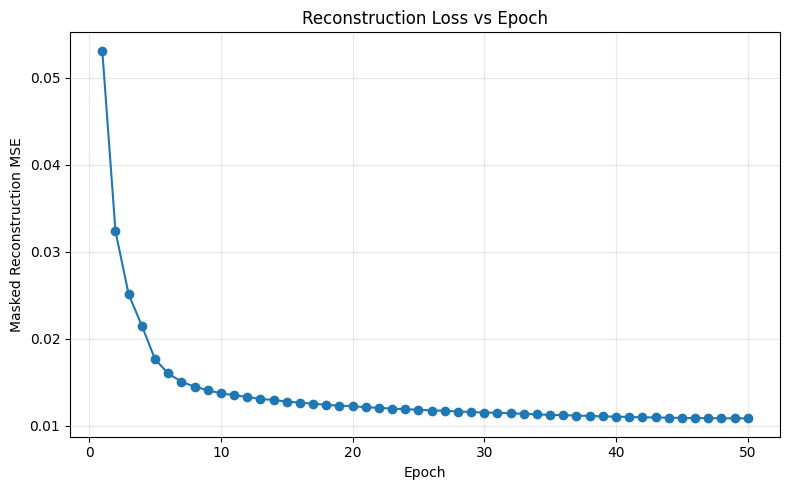

Saved: /kaggle/working/mae_outputs/train_loss.png


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Masked Reconstruction MSE')
plt.title('Reconstruction Loss vs Epoch')
plt.grid(alpha=0.3)
plt.tight_layout()
loss_plot_path = os.path.join(SAVE_DIR, 'train_loss.png')
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print('Saved:', loss_plot_path)

## Qualitative Reconstructions (5 samples)

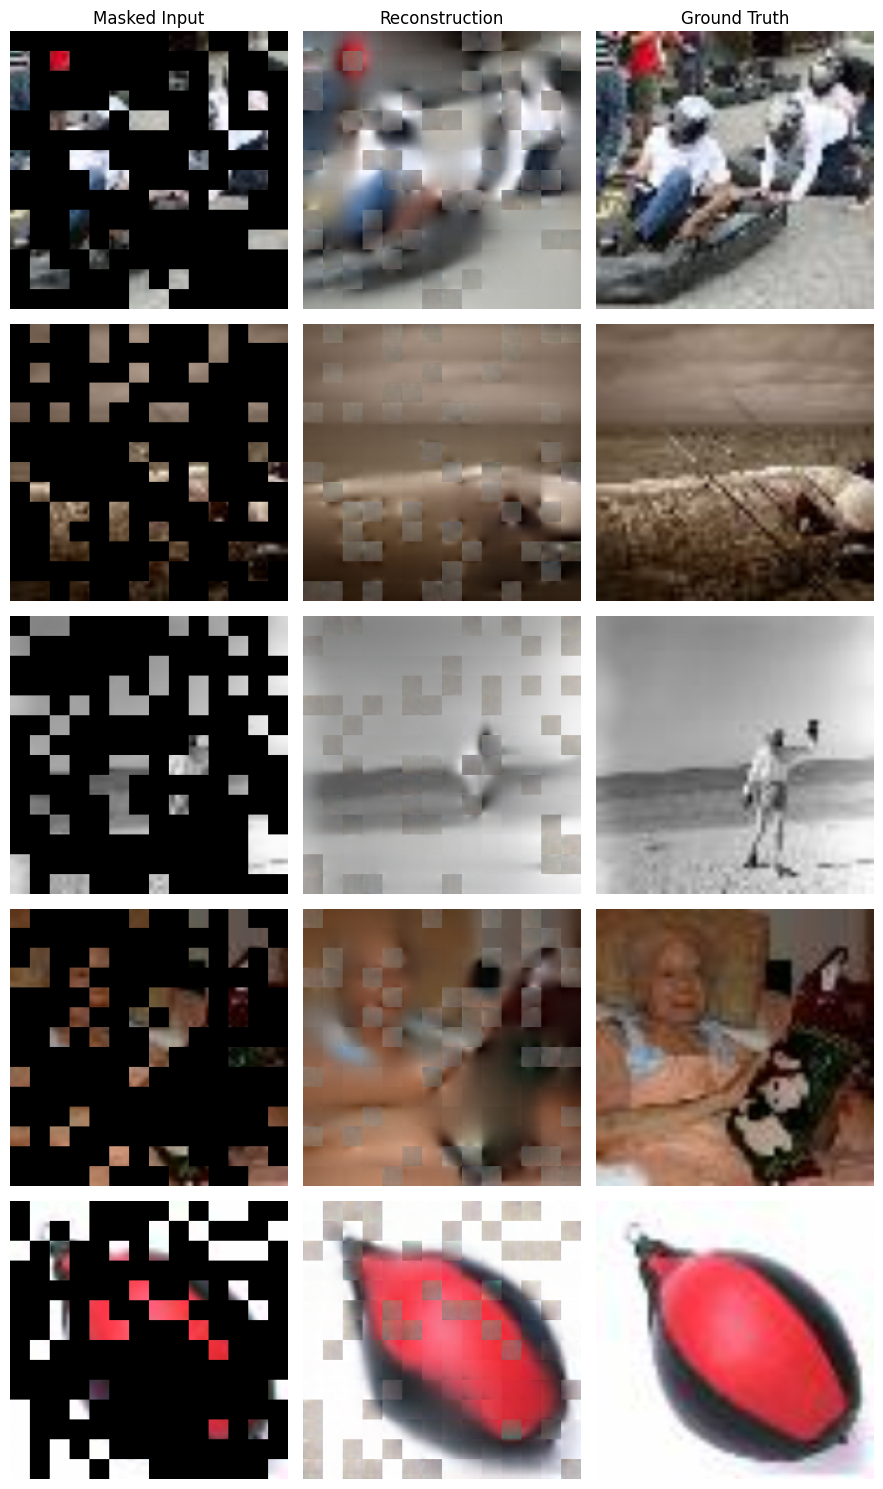

Saved: /kaggle/working/mae_outputs/recon_samples.png


In [11]:
raw_model = model.module if isinstance(model, nn.DataParallel) else model
recon_path = os.path.join(SAVE_DIR, 'recon_samples.png')
visualize_reconstructions(raw_model, val_loader, device, recon_path, n_samples=5)
print('Saved:', recon_path)

## Quantitative Evaluation (PSNR, SSIM)

In [12]:
raw_model = model.module if isinstance(model, nn.DataParallel) else model
psnr, ssim = evaluate_metrics(raw_model, val_loader, device, max_batches=10)
print(f'PSNR: {psnr:.4f}')
print(f'SSIM: {ssim:.4f}')

with open(os.path.join(SAVE_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write(f'PSNR: {psnr:.4f}\n')
    f.write(f'SSIM: {ssim:.4f}\n')

print('Saved:', os.path.join(SAVE_DIR, 'metrics.txt'))

PSNR: 18.6491
SSIM: 0.5569
Saved: /kaggle/working/mae_outputs/metrics.txt
